Account Ownership Forecast (2025–2027)
   Year  Baseline  Lower95CI  Upper95CI  Optimistic  Pessimistic
0  2025     55.68      42.30      69.07       62.51        48.86
1  2026     58.50      45.11      71.89       65.33        51.67
2  2027     61.32      47.93      74.70       68.14        54.49


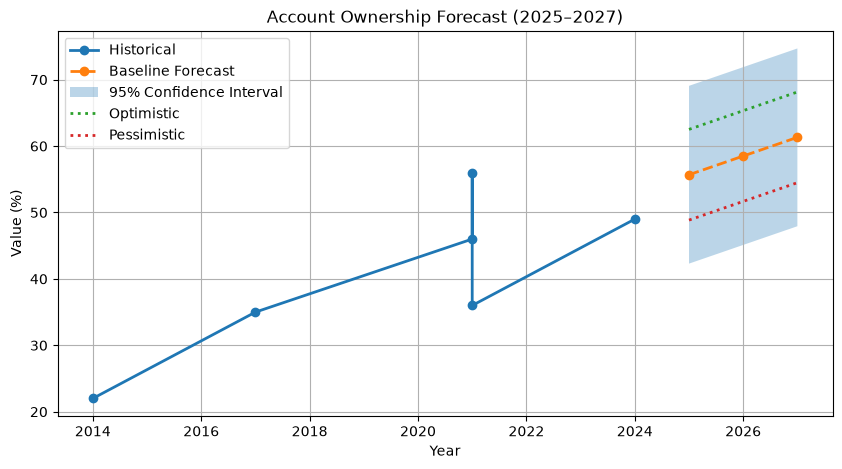

Mobile Money Account Forecast (2025–2027)
   Year  Baseline  Lower95CI  Upper95CI  Optimistic  Pessimistic
0  2025     11.03      11.03      11.03       11.03        11.03
1  2026     12.62      12.62      12.62       12.62        12.62
2  2027     14.20      14.20      14.20       14.20        14.20


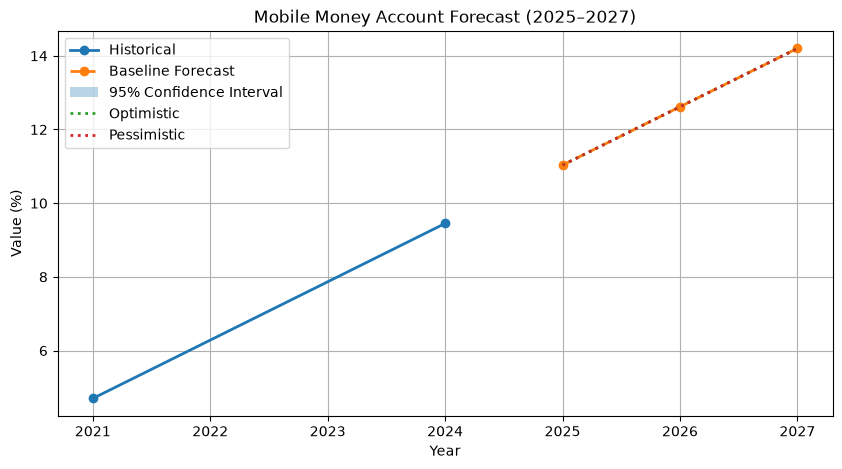

Forecast tables saved successfully.


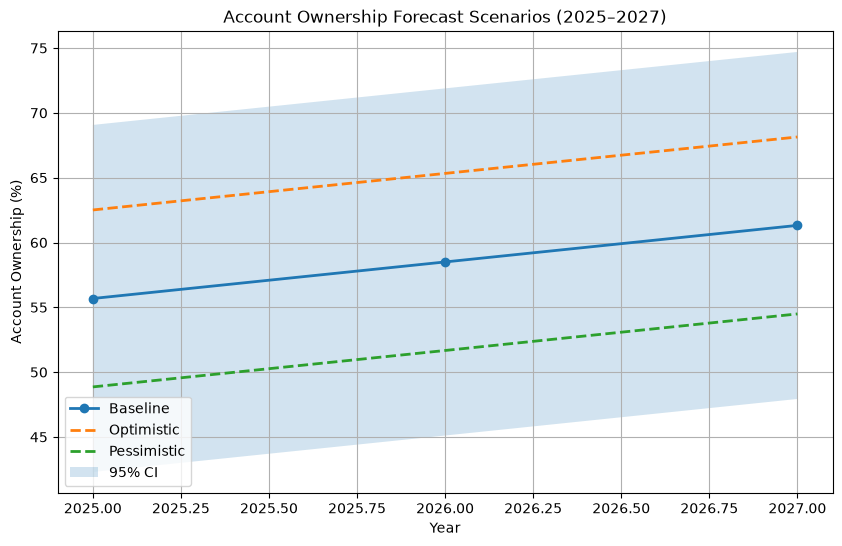

In [9]:
# ==============================
# TASK 4: Forecasting (One Cell)
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ------------------------------
# Load Dataset
# ------------------------------
#df = pd.read_csv("../data/processed/ethiopia_fi_enriched.csv")   # Change path if needed
df = pd.read_csv("../data/processed/ethiopia_fi_enriched_data.csv")

# ------------------------------
# Function for Forecasting
# ------------------------------
def forecast_indicator(df, indicator_code, title):
    
    data = df[
        (df["record_type"]=="observation") &
        (df["indicator_code"]==indicator_code)
    ].copy()

    data["year"] = pd.to_datetime(data["observation_date"]).dt.year
    data = data.sort_values("year")

    X = data[["year"]]
    y = data["value_numeric"]

    # Train Model
    model = LinearRegression()
    model.fit(X, y)

    # Historical Predictions
    fitted = model.predict(X)

    # Future Years
    future = pd.DataFrame({
        "year":[2025,2026,2027]
    })

    baseline = model.predict(future)

    # Residual Standard Error
    residuals = y - fitted
    std = residuals.std()

    # Confidence Interval
    lower = baseline - 1.96*std
    upper = baseline + 1.96*std

    # Scenario Forecasts
    optimistic = baseline + std
    pessimistic = baseline - std

    forecast = pd.DataFrame({
        "Year":future["year"],
        "Baseline":baseline.round(2),
        "Lower95CI":lower.round(2),
        "Upper95CI":upper.round(2),
        "Optimistic":optimistic.round(2),
        "Pessimistic":pessimistic.round(2)
    })

    print("="*60)
    print(title)
    print("="*60)
    print(forecast)

    # Plot
    plt.figure(figsize=(10,5))

    plt.plot(
        data["year"],
        y,
        marker="o",
        linewidth=2,
        label="Historical"
    )

    plt.plot(
        future["year"],
        baseline,
        marker="o",
        linestyle="--",
        linewidth=2,
        label="Baseline Forecast"
    )

    plt.fill_between(
        future["year"],
        lower,
        upper,
        alpha=0.3,
        label="95% Confidence Interval"
    )

    plt.plot(
        future["year"],
        optimistic,
        linestyle=":",
        linewidth=2,
        label="Optimistic"
    )

    plt.plot(
        future["year"],
        pessimistic,
        linestyle=":",
        linewidth=2,
        label="Pessimistic"
    )

    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel("Value (%)")
    plt.grid(True)
    plt.legend()
    plt.show()

    return forecast

# ------------------------------
# Account Ownership Forecast
# ------------------------------
account_forecast = forecast_indicator(
    df,
    "ACC_OWNERSHIP",
    "Account Ownership Forecast (2025–2027)"
)

# ------------------------------
# Digital Payment Usage Forecast
# ------------------------------
digital_forecast = forecast_indicator(
    df,
    "ACC_MM_ACCOUNT",
    "Mobile Money Account Forecast (2025–2027)"
)

# Save forecast tables
account_forecast.to_csv("../reports/account_ownership_forecast.csv", index=False)
digital_forecast.to_csv("../reports/mobile_money_forecast.csv", index=False)

print("Forecast tables saved successfully.")

plt.figure(figsize=(10,6))

plt.plot(account_forecast["Year"], account_forecast["Baseline"],
         marker="o", linewidth=2, label="Baseline")

plt.plot(account_forecast["Year"], account_forecast["Optimistic"],
         linestyle="--", linewidth=2, label="Optimistic")

plt.plot(account_forecast["Year"], account_forecast["Pessimistic"],
         linestyle="--", linewidth=2, label="Pessimistic")

plt.fill_between(
    account_forecast["Year"],
    account_forecast["Lower95CI"],
    account_forecast["Upper95CI"],
    alpha=0.2,
    label="95% CI"
)

plt.title("Account Ownership Forecast Scenarios (2025–2027)")
plt.xlabel("Year")
plt.ylabel("Account Ownership (%)")
plt.grid(True)
plt.legend()
plt.show()


